# Mandatory Part

### Loading the data

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


train_transform = transforms.Compose([
   transforms.RandomHorizontalFlip(p=0.5), # 50% chance to flip horizontally
   transforms.RandomVerticalFlip(p=0.5),   # 50% chance to flip vertically
   transforms.RandomRotation(degrees=45),  # Randomly rotate between -45 and +45 degrees
   transforms.ToTensor(),
   transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) 
 ])

# Testing Transforms
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load datasets applying the distinct transforms
train_dir = 'data/train' 
test_dir = 'data/test'   
ood_dir = 'id_ood_samples'

train_data = datasets.ImageFolder(root=train_dir, transform=train_transform)
test_data = datasets.ImageFolder(root=test_dir, transform=test_transform)


train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size

# Split the dataset
train_subset, val_subset = random_split(train_data, [train_size, val_size])

# Create the new DataLoaders
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)


### Basic CNN structure

In [2]:
class BaseCNN(nn.Module):
    def __init__(self):
        super(BaseCNN, self).__init__()
        # Input: 3 channels (RGB), 56x56 images
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: 16 channels, 28x28
            
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  # Output: 32 channels, 14x14
        )
        
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 14 * 14, 128),
            nn.ReLU(),
            nn.Linear(128, 8) # 8 output classes
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model = BaseCNN()

### Batch Normalization CNN

In [ ]:
class BatchNormCNN(nn.Module):
    def __init__(self):
        super(BatchNormCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),  # Normalizes the 16 feature maps
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),  # Normalizes the 32 feature maps
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  
        )
        
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 14 * 14, 128),
            nn.BatchNorm1d(128), # Normalizes the 128 nodes
            nn.ReLU(),
            nn.Linear(128, 8) 
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


### Training loop

In [4]:
import copy
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BatchNormCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

epochs = 40
patience = 5
train_losses = []
val_losses = []

best_val_loss = float('inf')
epochs_no_improve = 0
best_model_weights = copy.deepcopy(model.state_dict())

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        
        # Forward pass, backward pass, optimize
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad(): # No gradients needed for validation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            
    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    scheduler.step(avg_val_loss)
    
# Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s).")
        
        if epochs_no_improve >= patience:
            print("Early stopping triggered! Restoring best model weights.")
            break 
# Load the best weights back into the model before final testing
model.load_state_dict(best_model_weights)
torch.save(model.state_dict(), 'model_weights_c.pth')

Epoch 1/40 - Train Loss: 1.1368 | Val Loss: 0.9601
Epoch 2/40 - Train Loss: 0.9078 | Val Loss: 0.8553
Epoch 3/40 - Train Loss: 0.8259 | Val Loss: 0.8434
Epoch 4/40 - Train Loss: 0.7734 | Val Loss: 0.7337
Epoch 5/40 - Train Loss: 0.7401 | Val Loss: 0.7086
Epoch 6/40 - Train Loss: 0.7121 | Val Loss: 0.7053
Epoch 7/40 - Train Loss: 0.6887 | Val Loss: 0.6675
Epoch 8/40 - Train Loss: 0.6726 | Val Loss: 0.6861
No improvement for 1 epoch(s).
Epoch 9/40 - Train Loss: 0.6594 | Val Loss: 0.7210
No improvement for 2 epoch(s).
Epoch 10/40 - Train Loss: 0.6505 | Val Loss: 0.6568
Epoch 11/40 - Train Loss: 0.6345 | Val Loss: 0.6767
No improvement for 1 epoch(s).
Epoch 12/40 - Train Loss: 0.6148 | Val Loss: 0.6356
Epoch 13/40 - Train Loss: 0.6117 | Val Loss: 0.6629
No improvement for 1 epoch(s).
Epoch 14/40 - Train Loss: 0.6081 | Val Loss: 0.6255
Epoch 15/40 - Train Loss: 0.5974 | Val Loss: 0.6640
No improvement for 1 epoch(s).
Epoch 16/40 - Train Loss: 0.5875 | Val Loss: 0.6214
Epoch 17/40 - Train Lo

### Evaluation 

Baseline Test Accuracy: 82.30%


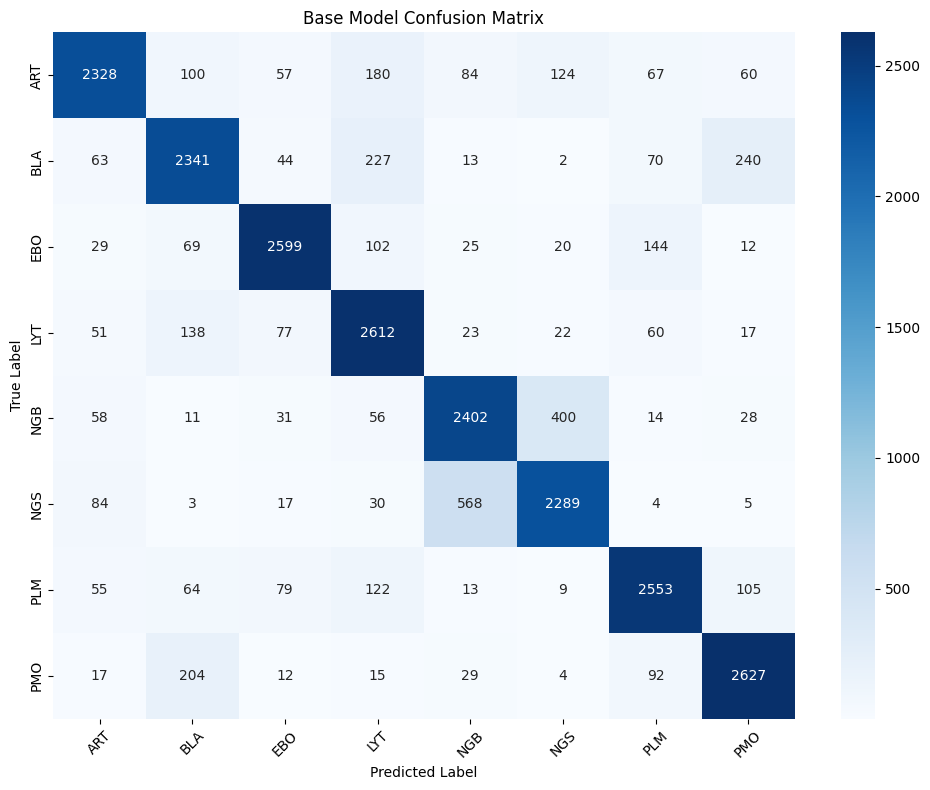

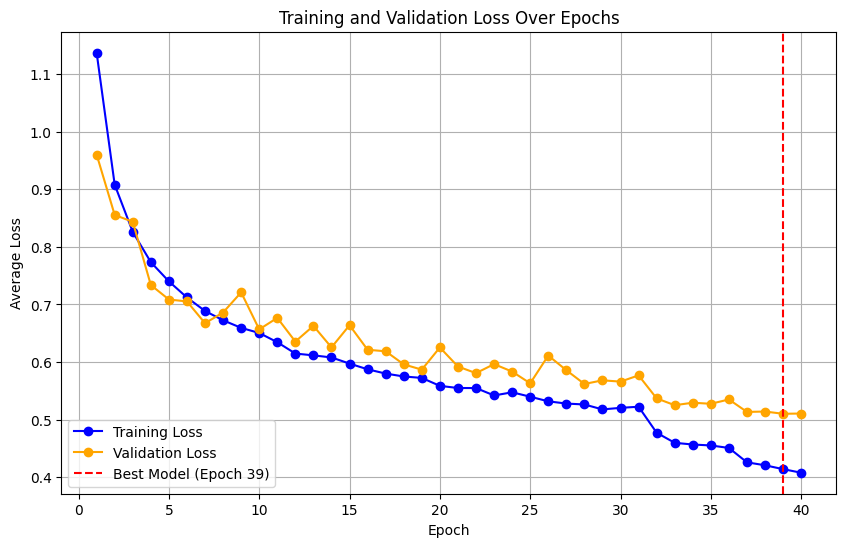

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score


model.eval()

# Lists to keep track of predictions and true labels
all_preds = []
all_labels = []

#Disable gradient calculation for inference 
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Get the network's predictions
        outputs = model(images)
        
        # The predicted class is the one with the highest probability
        _, predicted = torch.max(outputs.data, 1)
        
        # Move data back to CPU to use with scikit-learn and matplotlib
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate Overall Accuracy
accuracy = accuracy_score(all_labels, all_preds)
print(f"Baseline Test Accuracy: {accuracy * 100:.2f}%")

# Generate and Plot the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=test_data.classes, 
            yticklabels=test_data.classes)

plt.title('Base Model Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Loss vs epochs plot
plt.figure(figsize=(10, 6))
# Plot both lines
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', marker='o', color='blue')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss', marker='o', color='orange')

# Add a vertical line to show where the best model was found
best_epoch = len(train_losses) - epochs_no_improve
plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Model (Epoch {best_epoch})')

plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.legend()
plt.grid(True)
plt.show()

### Visualizing Predictions

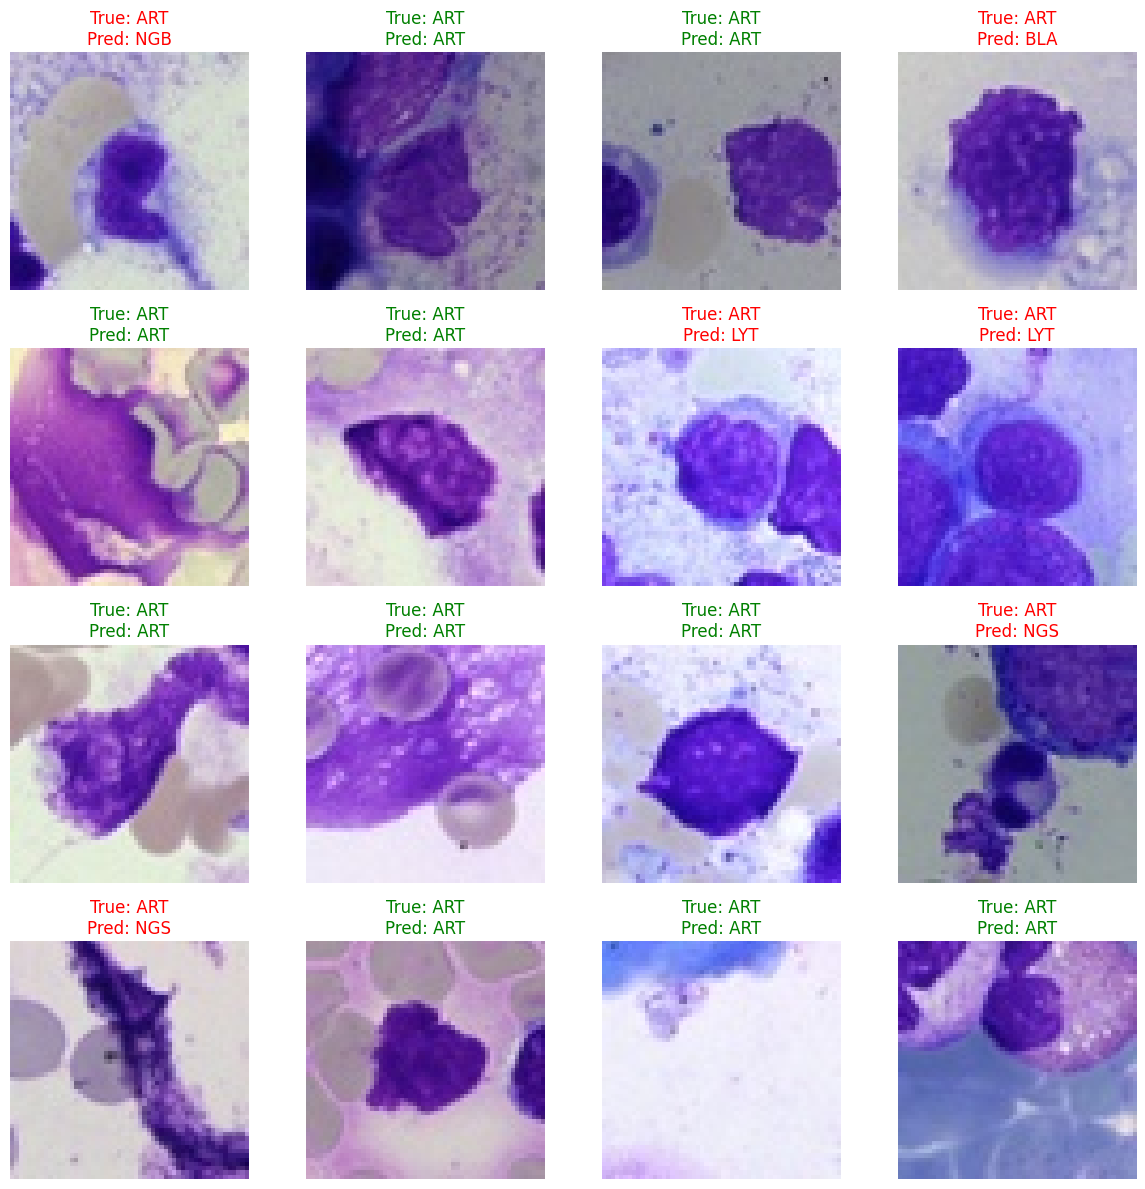

In [6]:
import matplotlib.pyplot as plt
import numpy as np

dataiter = iter(test_loader)
images, labels = next(dataiter)

model.eval()
with torch.no_grad():
    images = images.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

images = images.cpu()
predicted = predicted.cpu()
labels = labels.cpu()

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
class_names = test_data.classes 

for i, ax in enumerate(axes.flatten()):
    img = images[i].numpy().transpose((1, 2, 0))
    img = 0.5 * img + 0.5 
    img = np.clip(img, 0, 1)
    
    ax.imshow(img)
    ax.axis('off')
    
    # Check if correct
    is_correct = predicted[i] == labels[i]
    true_label = class_names[labels[i]]
    pred_label = class_names[predicted[i]]
    
    # Set border color (Green = Correct, Red = Incorrect)
    color = 'green' if is_correct else 'red'
    
    # Add the text and a colored box
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color)
    
    # Draw the border
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(4)
        spine.set_visible(True)

plt.tight_layout()
plt.show()

# Advanced Part

### Loading ID/OOD samples

In [7]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import numpy as np

class MixedUnlabeledDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        # Grab all image files in the directory
        self.image_files = [f for f in os.listdir(image_dir) if f.endswith(( '.jpg'))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_name)
        
        # Open image and ensure it has 3 color channels (RGB)
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        # Return the image and its path so we know which is which
        return image, img_path


# Use the test_transform (NO augmentation)
mixed_data = MixedUnlabeledDataset(image_dir='id_ood_samples', transform=test_transform)
mixed_loader = DataLoader(mixed_data, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

### Extraction

In [8]:
import torch.nn.functional as F
import numpy as np
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BatchNormCNN().to(device)

def get_msp_scores(model, dataloader):
    """
    Runs a dataloader through the model and returns the Maximum Softmax Probability 
    for each image.
    """ 
    model.load_state_dict(torch.load("model_weights_fin.pth", weights_only=True))
    model.eval()
    all_scores = []
    all_paths = []

    
    with torch.no_grad():
        for images, paths in dataloader:
            images = images.to(device)
            outputs = model(images)
            
            # Get probabilities
            probs = F.softmax(outputs, dim=1)
            
            # Maximum Softmax Probability (MSP)
            max_probs, _ = torch.max(probs, dim=1)
            
            all_scores.extend(max_probs.cpu().numpy())
            all_paths.extend(paths)
            
    return np.array(all_scores), np.array(all_paths)
mixed_scores, mixed_paths = get_msp_scores(model, mixed_loader)


### Plotting the histogram

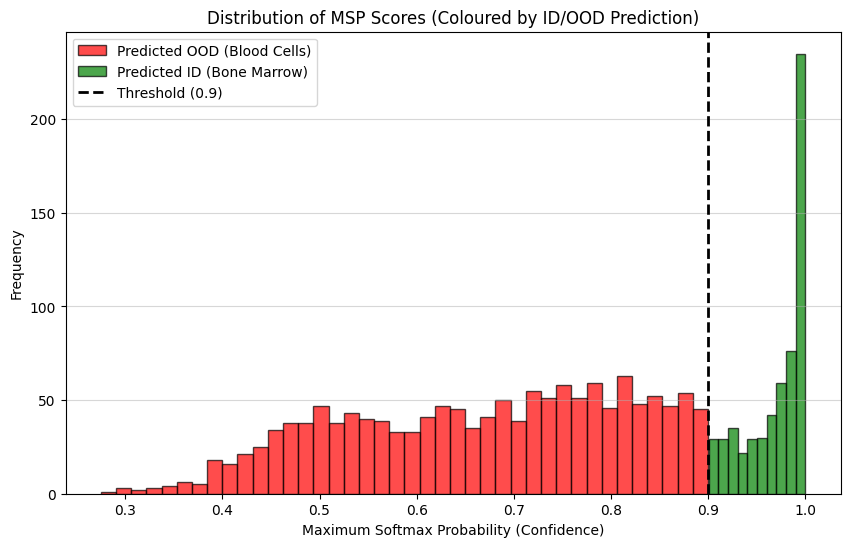

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Let's say any score below 0.90 is OOD, and above 0.90 is ID
threshold = 0.90

# Split the scores based on threshold
ood_predicted = mixed_scores[mixed_scores < threshold]
id_predicted = mixed_scores[mixed_scores >= threshold]

plt.figure(figsize=(10, 6))

# Plot the OOD hill in Red
plt.hist(ood_predicted, bins=40, alpha=0.7, color='red', edgecolor='black', label='Predicted OOD (Blood Cells)')

# Plot the ID hill in Green
plt.hist(id_predicted, bins=10, alpha=0.7, color='green', edgecolor='black', label='Predicted ID (Bone Marrow)')

plt.title('Distribution of MSP Scores (Coloured by ID/OOD Prediction)')
plt.xlabel('Maximum Softmax Probability (Confidence)')
plt.ylabel('Frequency')
plt.axvline(threshold, color='black', linestyle='dashed', linewidth=2, label=f'Threshold ({threshold})')
plt.legend(loc='upper left')
plt.grid(axis='y', alpha=0.5)
plt.show()

### Images

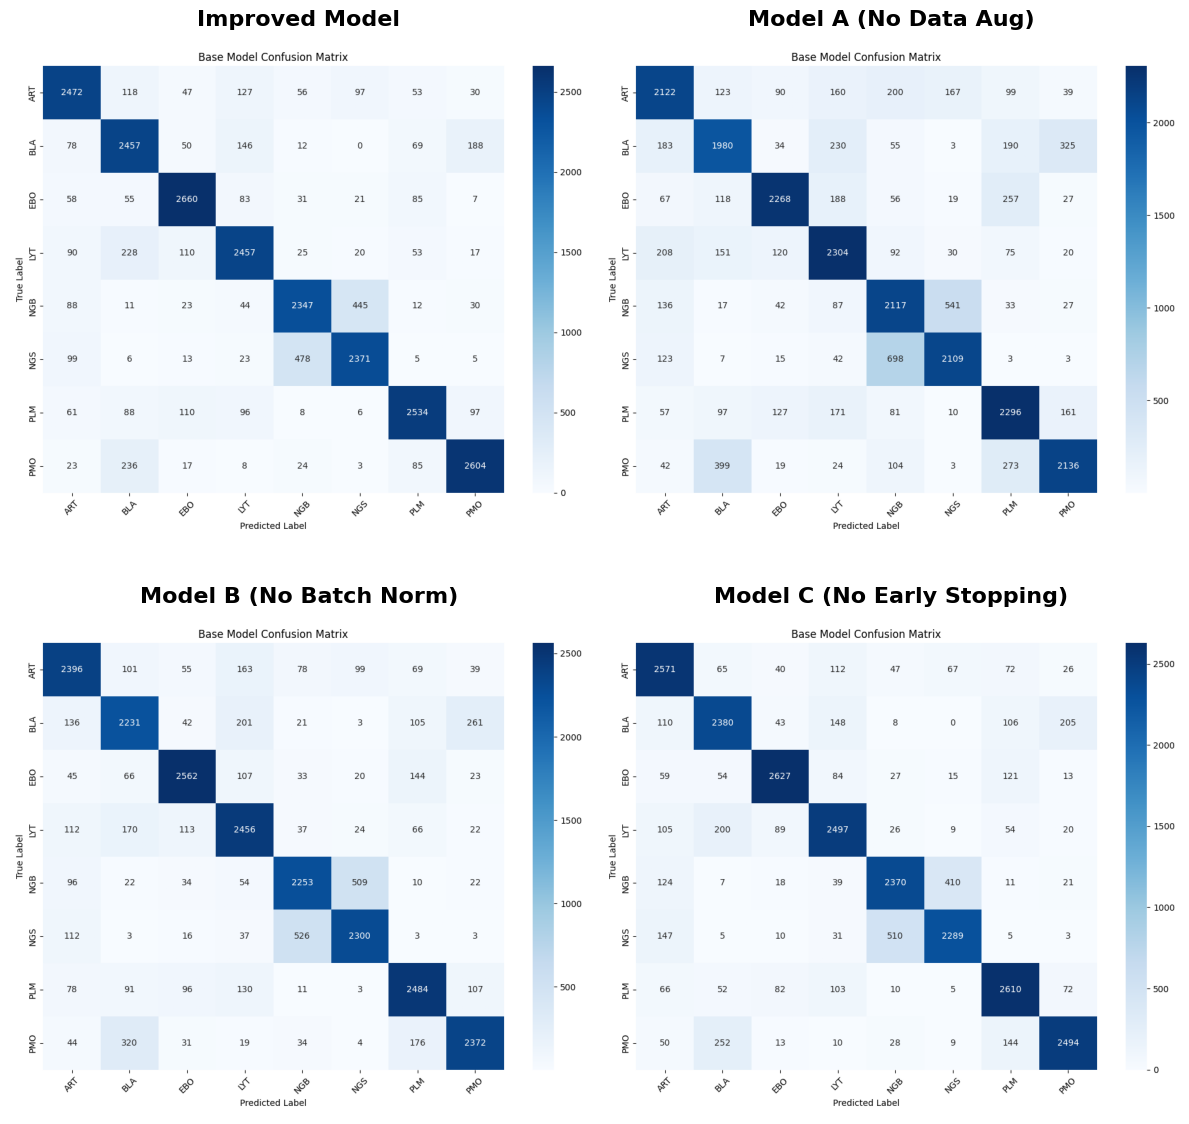

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image_paths = [
    'confusion_mat_final.png',  # Top-Left
    'confusion_mat_a.png', # Top-Right
    'confusion_mat_b.png', # Bottom-Left
    'confusion_mat_c.png'  # Bottom-Right
]

titles = [
    'Improved Model', 
    'Model A (No Data Aug)', 
    'Model B (No Batch Norm)', 
    'Model C (No Early Stopping)'
]

# Create the 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for i, ax in enumerate(axes.flatten()):
    # Read and display the image
    img = mpimg.imread(image_paths[i])
    ax.imshow(img)
    
    # Add the title and hide the ugly axis numbers
    ax.set_title(titles[i], fontsize=16, fontweight='bold', pad=15)
    ax.axis('off')

# Save it as a single high-quality image!
plt.tight_layout()
plt.savefig('combined_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()